In [ ]:
import os, re
import pandas as pd

# This code aims to convert old formatted files into the train_samples.txt in dashboard to more efficiently manage the dataset.

def gen_list(src_name, tgt_name, write_to=True):
    tmp_data_path = f'/compute001/lwu/projects/GANomics_fullsource/trans_gan_project/run_datasets/{src_name}/trainAG'
    target_path = f'/compute001/lwu/projects/GANomics/dashboard/backend/results_ms/1_Training/checkpoints/{tgt_name}/train_samples.txt'
    if write_to is True:
        with open(target_path, 'w') as f:     
            for file in os.listdir(tmp_data_path):
                f.write(re.sub('.txt','',file)+'\n')
            print(src_name, 'Done.')
    else:
        for file in os.listdir(tmp_data_path):
            print(re.sub('.txt','',file))
    
    return

In [21]:
file_mapping = pd.read_csv('ms_mapping.txt',sep="\t",header=None)
file_mapping.columns=['tgt_name', 'src_name']
for ind, d in file_mapping.iterrows():
    gen_list(d['src_name'], d['tgt_name'], write_to=True)
    # if ind >3: break

datasets_BRCA1/tmp_10_0 Done.
datasets_BRCA1/tmp_100_0 Done.
datasets_BRCA1/tmp_150_0 Done.
datasets_BRCA1/tmp_20_0 Done.
datasets_BRCA1/tmp_50_0 Done.
datasets_BRCA2/tmp_10_0 Done.
datasets_BRCA2/tmp_100_0 Done.
datasets_BRCA2/tmp_50_0 Done.
datasets_NB_noFB/tmp_50_0 Done.
datasets_NB_noFB/tmp_50_1 Done.
datasets_NB_noFB/tmp_50_2 Done.
datasets_NB_noFB/tmp_50_3 Done.
datasets_NB_noFB/tmp_50_4 Done.
datasets_LAML1/tmp_50_0 Done.
datasets_LUSC1/tmp_50_0 Done.
datasets_METSIM/tmp_10_0 Done.
datasets_METSIM/tmp_100_0 Done.
datasets_METSIM/tmp_20_0 Done.
datasets_METSIM/tmp_50_0 Done.
datasets_NB/tmp_10_0 Done.
datasets_NB/tmp_10_1 Done.
datasets_NB/tmp_10_2 Done.
datasets_NB/tmp_10_3 Done.
datasets_NB/tmp_10_4 Done.
datasets_NB/tmp_20_0 Done.
datasets_NB/tmp_20_1 Done.
datasets_NB/tmp_20_2 Done.
datasets_NB/tmp_20_3 Done.
datasets_NB/tmp_20_4 Done.
datasets_NB/tmp_30_0 Done.
datasets_NB/tmp_30_1 Done.
datasets_NB/tmp_30_2 Done.
datasets_NB/tmp_30_3 Done.
datasets_NB/tmp_30_4 Done.
dataset

Pearson | Microarray: t = 8.3451, p=0.001
Pearson | RNAseq: t = 6.5810, p=0.003
Spearman | Microarray: t = 9.0035, p<0.001
Spearman | RNAseq: t = 6.5855, p=0.003
L1 | Microarray: t = -2.8050, p=0.048
L1 | RNAseq: t = -4.9170, p=0.008


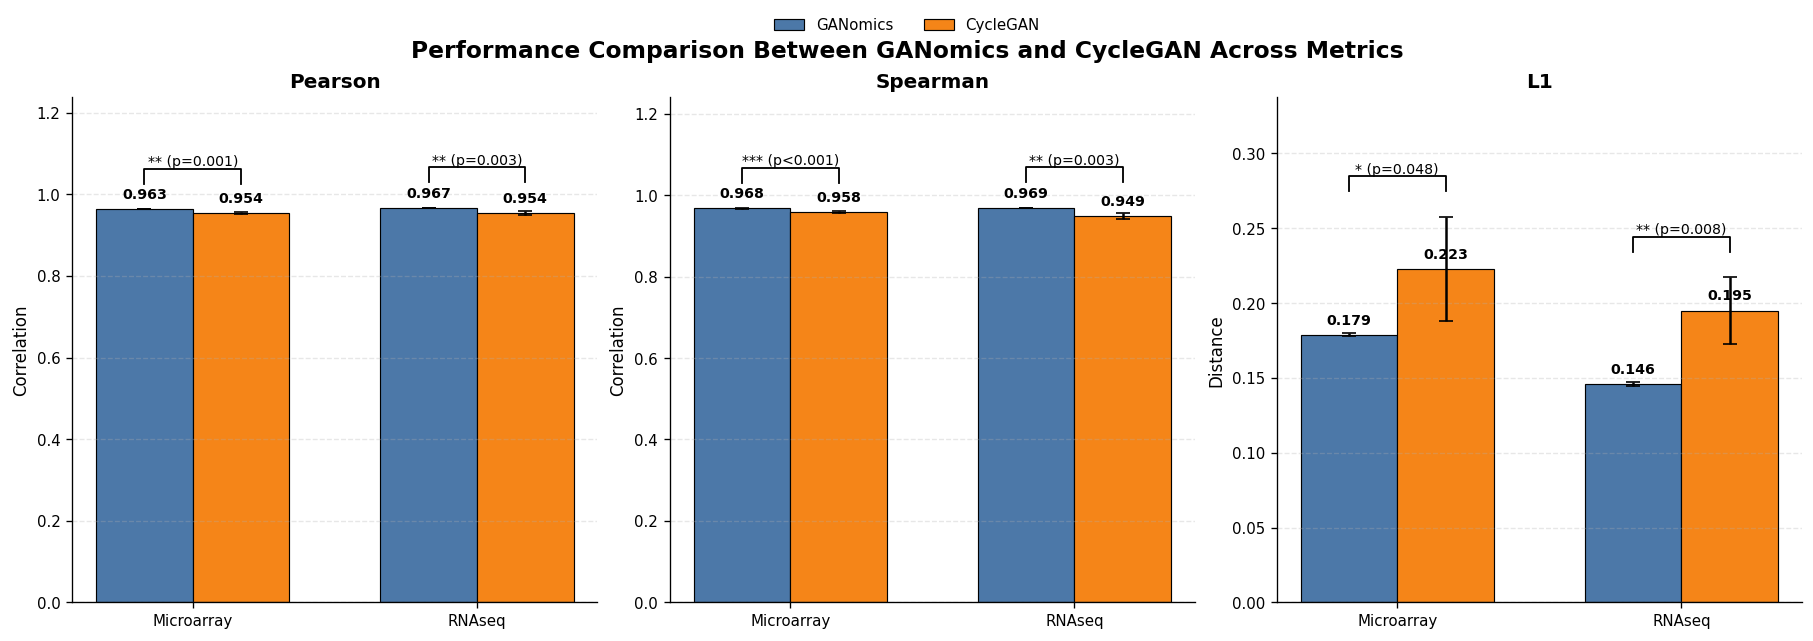

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================
# Configuration
# =========================
FILE_PATH = "../Alignment_result_ms.xlsx"
METHOD_PATTERNS = {
    "GANomics": "run",
    "CycleGAN": "CycleGAN"
}
PLATFORMS = ["Microarray", "RNAseq"]
METRICS = ["Pearson", "Spearman", "L1"]

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# =========================
# Helper functions
# =========================
def significance_label(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"


def format_p_value(p):
    if p < 0.001:
        return "p<0.001"
    return f"p={p:.3f}"


def get_series(df, task_pattern, platform, metric):
    return df[
        df["Task"].str.contains(task_pattern, case=False, na=False) &
        (df["Platform"] == platform)
    ][metric].dropna()


def welch_ttest(x, y):
    return ttest_ind(x, y, equal_var=False, nan_policy="omit")


def add_value_labels(ax, bars, values, y_offset_ratio=0.015):
    ymin, ymax = ax.get_ylim()
    offset = (ymax - ymin) * y_offset_ratio
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold"
        )


def add_sig_bracket(ax, x1, x2, y, h, p_val, fontsize=8.5):
    text = f"{significance_label(p_val)} ({format_p_value(p_val)})"
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.1, c="black")
    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=fontsize
    )


# =========================
# Load data
# =========================
df = pd.read_excel(FILE_PATH)

# =========================
# Prepare summary stats
# =========================
summary = []

for metric in METRICS:
    for platform in PLATFORMS:
        g1 = get_series(df, METHOD_PATTERNS["GANomics"], platform, metric)
        g2 = get_series(df, METHOD_PATTERNS["CycleGAN"], platform, metric)

        t_stat, p_val = welch_ttest(g1, g2)

        summary.append({
            "Metric": metric,
            "Platform": platform,
            "GANomics_mean": g1.mean(),
            "GANomics_std": g1.std(),
            "CycleGAN_mean": g2.mean(),
            "CycleGAN_std": g2.std(),
            "p_value": p_val,
            "t_stat": t_stat
        })

summary_df = pd.DataFrame(summary)

# Print stats
for _, row in summary_df.iterrows():
    print(
        f"{row['Metric']} | {row['Platform']}: "
        f"t = {row['t_stat']:.4f}, {format_p_value(row['p_value'])}"
    )

# =========================
# Plot
# =========================
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

colors = {
    "GANomics": "#4C78A8",
    "CycleGAN": "#F58518"
}

x = np.arange(len(PLATFORMS))   # [0, 1]
width = 0.34

for ax, metric in zip(axes, METRICS):
    data_m = summary_df[summary_df["Metric"] == metric].set_index("Platform").loc[PLATFORMS]

    gan_means = data_m["GANomics_mean"].values
    cyc_means = data_m["CycleGAN_mean"].values
    gan_stds = data_m["GANomics_std"].values
    cyc_stds = data_m["CycleGAN_std"].values
    p_vals = data_m["p_value"].values

    bars1 = ax.bar(
        x - width / 2,
        gan_means,
        width,
        yerr=gan_stds,
        capsize=4,
        label="GANomics",
        color=colors["GANomics"],
        edgecolor="black",
        linewidth=0.7
    )

    bars2 = ax.bar(
        x + width / 2,
        cyc_means,
        width,
        yerr=cyc_stds,
        capsize=4,
        label="CycleGAN",
        color=colors["CycleGAN"],
        edgecolor="black",
        linewidth=0.7
    )

    ax.set_title(metric, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(PLATFORMS)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    if metric in ["Pearson", "Spearman"]:
        ax.set_ylabel("Correlation")
    else:
        ax.set_ylabel("Distance")

    # Set y-limits with room for labels and p-values
    bar_tops = np.maximum(gan_means + gan_stds, cyc_means + cyc_stds)
    y_min = min(0, np.nanmin([gan_means - gan_stds, cyc_means - cyc_stds]))
    y_max = np.nanmax(bar_tops)

    # More headroom for annotations
    pad = max((y_max - y_min) * 0.28, 0.08 if y_max <= 1 else 0.15)
    ax.set_ylim(y_min, y_max + pad)

    # Add value labels
    add_value_labels(ax, bars1, gan_means)
    add_value_labels(ax, bars2, cyc_means)

    # Add significance bracket for each platform pair
    for i in range(len(x)):
        left_bar_x = x[i] - width / 2
        right_bar_x = x[i] + width / 2
        pair_top = max(gan_means[i] + gan_stds[i], cyc_means[i] + cyc_stds[i])

        h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03
        y = pair_top + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05

        add_sig_bracket(
            ax,
            left_bar_x,
            right_bar_x,
            y,
            h,
            p_vals[i]
        )

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05))

fig.suptitle(
    "Performance Comparison Between GANomics and CycleGAN Across Metrics",
    fontsize=14,
    fontweight="bold"
)

plt.show()

/tmp/ipykernel_1569510/3709074895.py:84: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1569510/3709074895.py:84: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


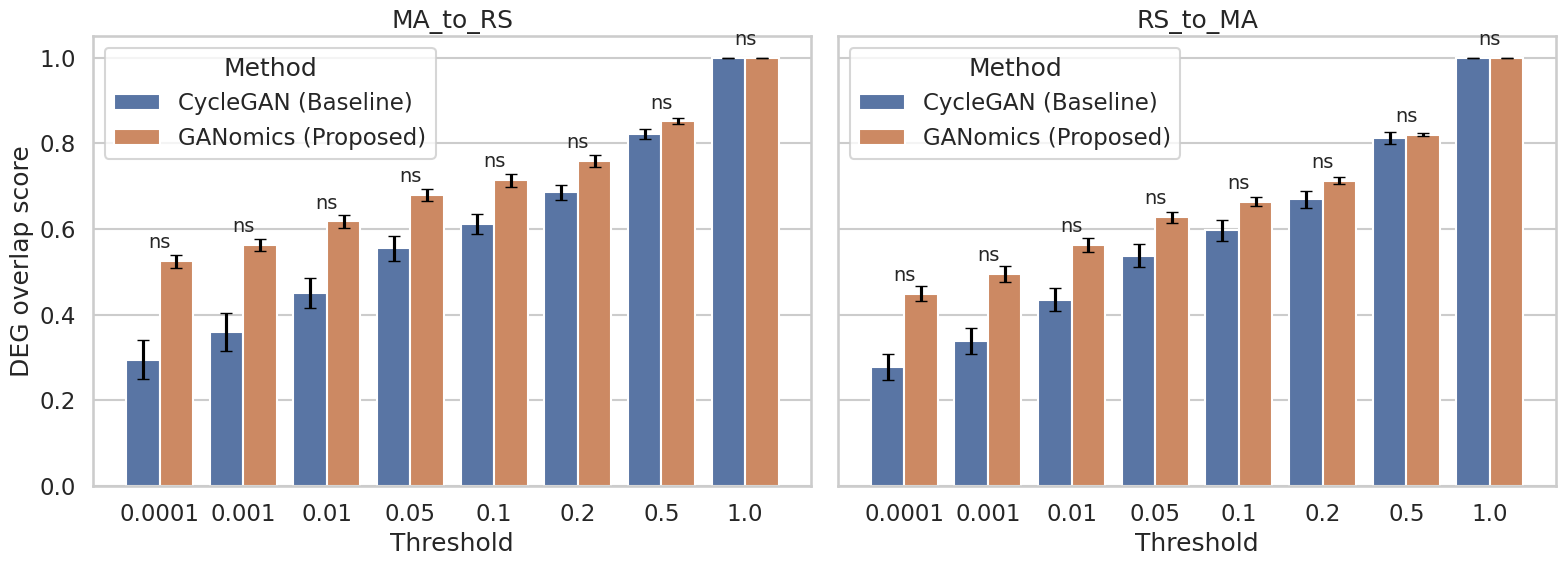

In [2]:
# ==========================================
# Compare CycleGAN vs GANomics DEG results
# ==========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind_from_stats
from statsmodels.stats.multitest import multipletests

sns.set(style="whitegrid", context="talk")

# -----------------------------
# Parameters
# -----------------------------
N_REPEATS = 5   # change if different

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("results/comparative_deg_curve.csv")

df["threshold"] = df["threshold"].astype(str)

# -----------------------------
# Statistical testing
# -----------------------------
pvals = []

for direction in df["Direction"].unique():
    for thr in df["threshold"].unique():

        sub = df[(df.Direction == direction) & (df.threshold == thr)]

        if len(sub) != 2:
            continue

        g1 = sub[sub.Method.str.contains("CycleGAN")].iloc[0]
        g2 = sub[sub.Method.str.contains("GANomics")].iloc[0]

        t, p = ttest_ind_from_stats(
            mean1=g1["mean"],
            std1=g1["std"],
            nobs1=N_REPEATS,
            mean2=g2["mean"],
            std2=g2["std"],
            nobs2=N_REPEATS,
            equal_var=False
        )

        pvals.append({
            "Direction": direction,
            "threshold": thr,
            "pval": p
        })

pval_df = pd.DataFrame(pvals)

# FDR correction
pval_df["p_adj"] = multipletests(pval_df["pval"], method="fdr_bh")[1]

# significance labels
def star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"

pval_df["sig"] = pval_df["p_adj"].apply(star)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

for ax, direction in zip(axes, df.Direction.unique()):

    sub = df[df.Direction == direction]

    sns.barplot(
        data=sub,
        x="threshold",
        y="mean",
        hue="Method",
        ax=ax,
        ci=None
    )

    # add error bars
    for i, row in sub.iterrows():
        x = list(sub["threshold"].unique()).index(row["threshold"])
        offset = -0.2 if "CycleGAN" in row["Method"] else 0.2

        ax.errorbar(
            x + offset,
            row["mean"],
            yerr=row["std"],
            fmt="none",
            c="black",
            capsize=4
        )

    # add significance annotation
    sig_sub = pval_df[pval_df.Direction == direction]

    for i, row in sig_sub.iterrows():
        x = list(sub["threshold"].unique()).index(row["threshold"])
        y = sub[sub.threshold == row["threshold"]]["mean"].max() + 0.03
        ax.text(x, y, row["sig"], ha='center', fontsize=14)

    ax.set_title(direction)
    ax.set_ylabel("DEG overlap score")
    ax.set_xlabel("Threshold")

plt.tight_layout()
plt.show()

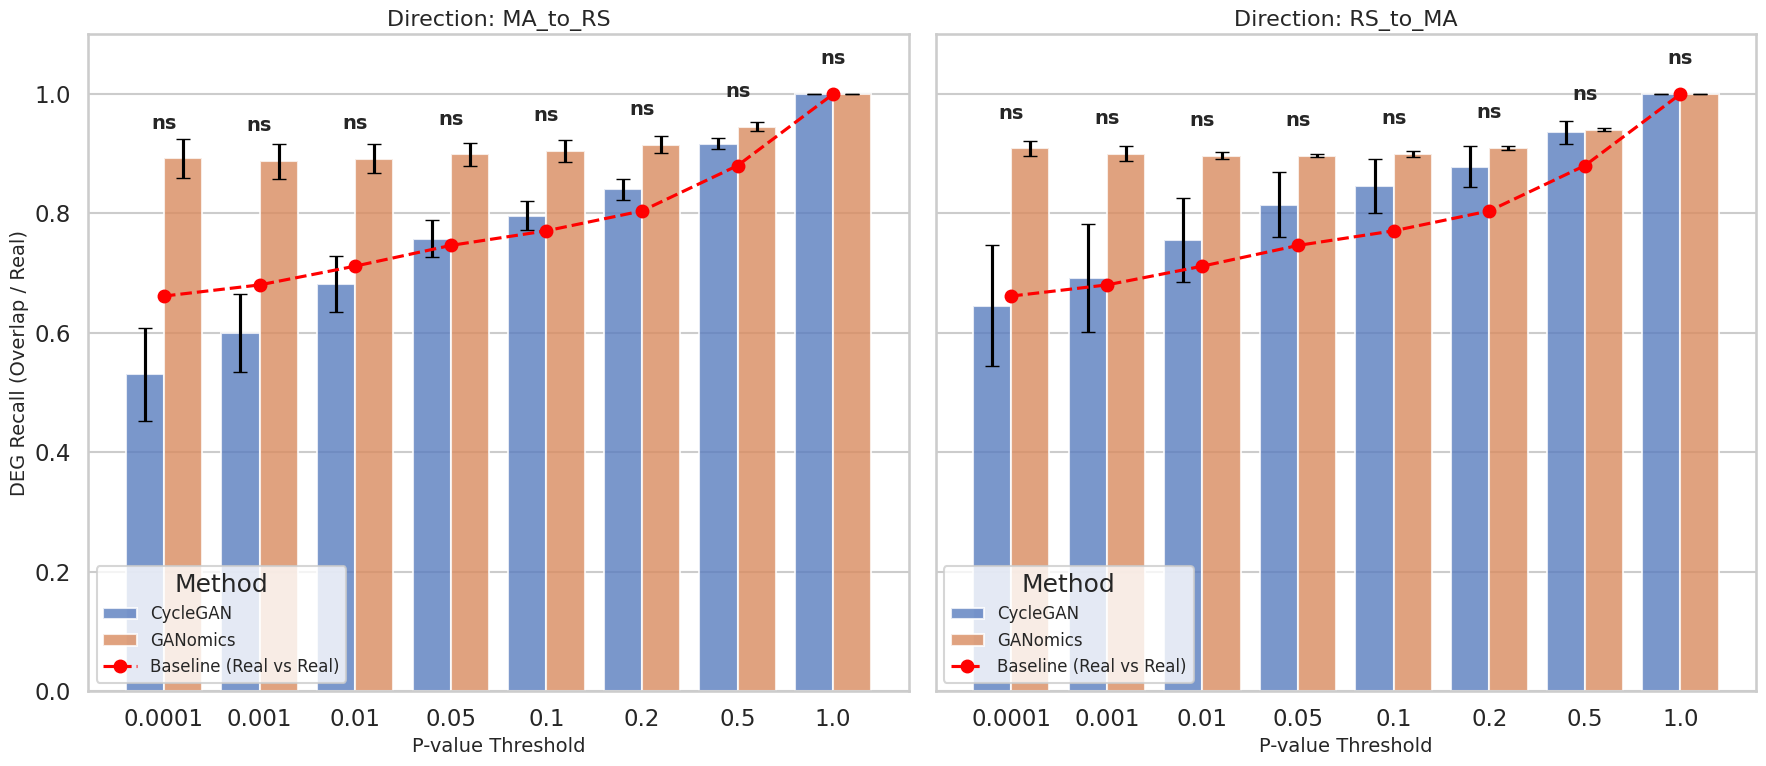

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind_from_stats
from statsmodels.stats.multitest import multipletests
import glob
import os

sns.set(style="whitegrid", context="talk")

# -----------------------------
# Parameters
# -----------------------------
base_path = "/compute001/lwu/projects/GANomics/dashboard/backend/results_ms/4_Biomarkers/DEG"
N_REPEATS = 5

# -----------------------------
# Load and process data
# -----------------------------
data_list = []
baseline_list = []

def process_folder(folder, method_name):
    for direction in ["MA_to_RS", "RS_to_MA"]:
        file_name = f"Jaccard_Curve_GANomics_{direction}.csv"
        file_path = os.path.join(folder, file_name)
        if os.path.exists(file_path):
            tmp_df = pd.read_csv(file_path)
            tmp_df["recall"] = tmp_df["n_overlap"] / tmp_df["n_real"]
            tmp_df["Method"] = method_name
            tmp_df["Direction"] = direction
            tmp_df["Folder"] = os.path.basename(folder)
            data_list.append(tmp_df)
    
    # Process baseline (only once per folder or once per direction? 
    # Usually Jaccard_Curve_Baseline.csv is the same for both directions because it's real vs real)
    baseline_path = os.path.join(folder, "Jaccard_Curve_Baseline.csv")
    if os.path.exists(baseline_path):
        tmp_df = pd.read_csv(baseline_path)
        tmp_df["recall"] = tmp_df["n_overlap"] / tmp_df["n_real"]
        tmp_df["Folder"] = os.path.basename(folder)
        baseline_list.append(tmp_df)


for sub_folder in os.listdir(base_path):
    if "NB_Size_50_run" in sub_folder:
        process_folder(os.path.join(base_path, sub_folder), "GANomics")
    if "CycleGAN_50_" in sub_folder:
        process_folder(os.path.join(base_path, sub_folder), "CycleGAN")

all_data = pd.concat(data_list, ignore_index=True)
all_baseline = pd.concat(baseline_list, ignore_index=True)

# Summarize baseline across all folders (or per folder type?)
# Let's just summarize all baselines since they should be similar
baseline_summary = all_baseline.groupby("threshold")["recall"].mean().reset_index()

# Summarize methods
summary_df = all_data.groupby(["Method", "Direction", "threshold"])["recall"].agg(["mean", "std"]).reset_index()
summary_df["threshold"] = summary_df["threshold"].astype(str)

# -----------------------------
# Statistical testing
# -----------------------------
pvals = []

for direction in summary_df["Direction"].unique():
    for thr in summary_df["threshold"].unique():
        sub = summary_df[(summary_df.Direction == direction) & (summary_df.threshold == str(thr))]
        
        if len(sub) < 2:
            continue
            
        g1 = sub[sub.Method == "CycleGAN"]
        g2 = sub[sub.Method == "GANomics"]
        
        if len(g1) == 0 or len(g2) == 0:
            continue
            
        g1 = g1.iloc[0]
        g2 = g2.iloc[0]
        
        t, p = ttest_ind_from_stats(
            mean1=g1["mean"],
            std1=g1["std"] if not pd.isna(g1["std"]) else 0,
            nobs1=N_REPEATS,
            mean2=g2["mean"],
            std2=g2["std"] if not pd.isna(g2["std"]) else 0,
            nobs2=N_REPEATS,
            equal_var=False
        )
        
        pvals.append({
            "Direction": direction,
            "threshold": thr,
            "pval": p
        })

pval_df = pd.DataFrame(pvals)

if not pval_df.empty:
    # FDR correction
    pval_df["p_adj"] = multipletests(pval_df["pval"], method="fdr_bh")[1]

    # significance labels
    def star(p):
        if p < 0.001: return "***"
        if p < 0.01: return "**"
        if p < 0.05: return "*"
        return "ns"

    pval_df["sig"] = pval_df["p_adj"].apply(star)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

for ax, direction in zip(axes, summary_df.Direction.unique()):
    sub = summary_df[summary_df.Direction == direction]
    
    # Sort thresholds numerically for plot
    sub["threshold_num"] = sub["threshold"].astype(float)
    sub = sub.sort_values("threshold_num")
    unique_thrs = sorted(sub["threshold_num"].unique())
    sub["threshold"] = pd.Categorical(sub["threshold"], categories=[str(t) for t in unique_thrs], ordered=True)

    sns.barplot(
        data=sub,
        x="threshold",
        y="mean",
        hue="Method",
        ax=ax,
        palette="muted",
        alpha=0.8
    )

    # Add error bars
    for i, row in sub.iterrows():
        # Find index in Categorical
        x_idx = list(sub["threshold"].unique()).index(row["threshold"])
        # seaborn hue offset is roughly +/- 0.2
        offset = -0.2 if row["Method"] == "CycleGAN" else 0.2

        ax.errorbar(
            x_idx + offset,
            row["mean"],
            yerr=row["std"] if not pd.isna(row["std"]) else 0,
            fmt="none",
            c="black",
            capsize=5
        )

    # Add baseline dashed line
    # Map baseline threshold to x-axis
    baseline_summary_sorted = baseline_summary.copy()
    baseline_summary_sorted = baseline_summary_sorted[baseline_summary_sorted["threshold"].isin(unique_thrs)]
    baseline_summary_sorted = baseline_summary_sorted.sort_values("threshold")
    
    # We can plot the baseline as a line across the bars
    # Since thresholds are discrete on x-axis, we can plot a step line or just points connected
    x_vals = range(len(unique_thrs))
    y_vals = baseline_summary_sorted["recall"].values
    
    ax.plot(x_vals, y_vals, linestyle="--", color="red", label="Baseline (Real vs Real)", marker="o")

    # Significance annotation
    if not pval_df.empty:
        sig_sub = pval_df[pval_df.Direction == direction]
        for i, row in sig_sub.iterrows():
            try:
                x_idx = list(sub["threshold"].unique()).index(str(row["threshold"]))
                y_max = sub[sub.threshold == str(row["threshold"])]["mean"].max()
                y_pos = max(y_max, baseline_summary[baseline_summary.threshold == float(row["threshold"])]["recall"].values[0]) + 0.05
                ax.text(x_idx, y_pos, row["sig"], ha='center', fontsize=14, fontweight="bold")
            except:
                continue

    ax.set_title(f"Direction: {direction}", fontsize=16)
    ax.set_ylabel("DEG Recall (Overlap / Real)", fontsize=14)
    ax.set_xlabel("P-value Threshold", fontsize=14)
    ax.legend(title="Method", fontsize=12)
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

/compute001/lwu/projects/GANomics/venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/compute001/lwu/projects/GANomics/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/compute001/lwu/projects/GANomics/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/compute001/lwu/projects/GANomics/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/compute001/lwu/projects/GANomics/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


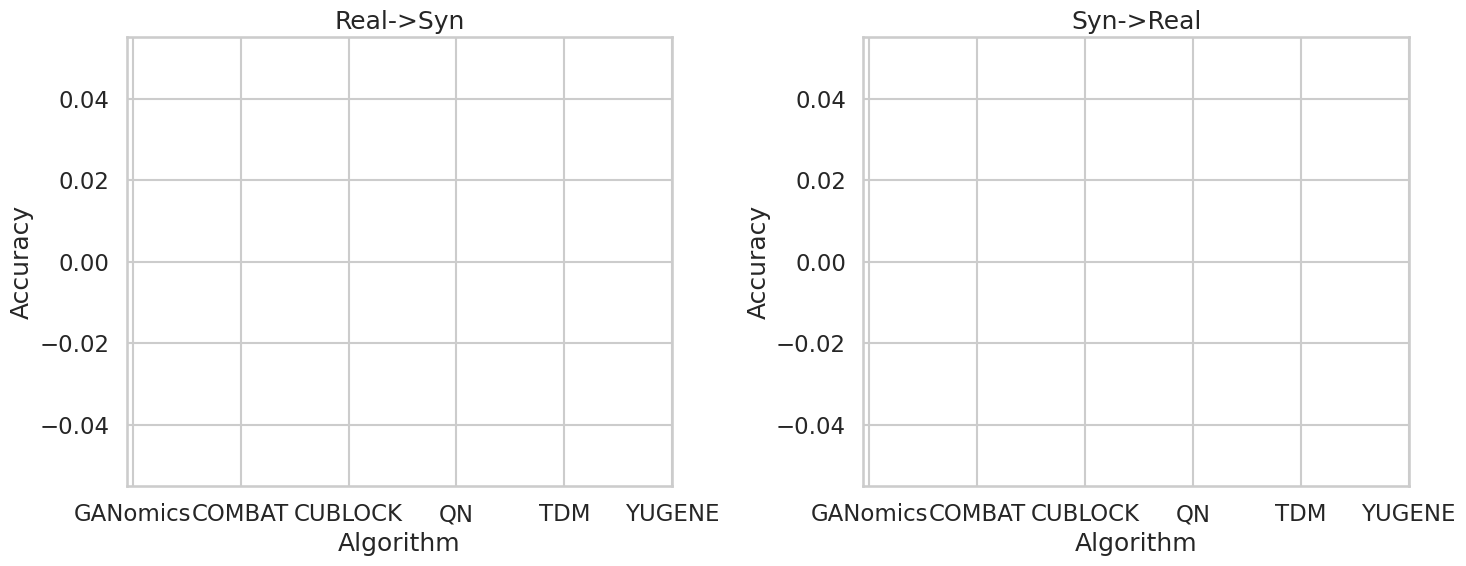

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Directories containing the results
directories = [
    'dashboard/backend/results/4_Biomarkers/Prediction/NB_Ablation_Size_50_Run_0',
    'dashboard/backend/results/4_Biomarkers/Prediction/NB_Ablation_Size_50_Run_1',
    'dashboard/backend/results/4_Biomarkers/Prediction/NB_Ablation_Size_50_Run_2',
    'dashboard/backend/results/4_Biomarkers/Prediction/NB_Ablation_Size_50_Run_3',
    'dashboard/backend/results/4_Biomarkers/Prediction/NB_Ablation_Size_50_Run_4'
]

# Algorithms to compare
algorithms = ['GANomics', 'COMBAT', 'CUBLOCK', 'QN', 'TDM', 'YUGENE']

# Scenarios to compare
scenarios = ['Real->Syn', 'Syn->Real']

# Initialize a dictionary to store the results
results = {algo: {scenario: [] for scenario in scenarios} for algo in algorithms}

# Aggregate results from the CSV files
for directory in directories:
    for algo in algorithms:
        file_path_ma = os.path.join(directory, f'Classifier_Performance_{algo}_MA.csv')
        file_path_rs = os.path.join(directory, f'Classifier_Performance_{algo}_RS.csv')
        
        if os.path.exists(file_path_ma) and os.path.exists(file_path_rs):
            df_ma = pd.read_csv(file_path_ma)
            df_rs = pd.read_csv(file_path_rs)
            
            for scenario in scenarios:
                accuracy_ma = df_ma.loc[df_ma['Scenario'] == scenario, 'Accuracy'].mean() if scenario in df_ma['Scenario'].values else np.nan
                accuracy_rs = df_rs.loc[df_rs['Scenario'] == scenario, 'Accuracy'].mean() if scenario in df_rs['Scenario'].values else np.nan
                
                # Store the average accuracy
                results[algo][scenario].append((accuracy_ma + accuracy_rs) / 2)

# Calculate mean and standard deviation for each algorithm and scenario
means = {algo: {scenario: np.mean(values) for scenario, values in results[algo].items()} for algo in algorithms}
stds = {algo: {scenario: np.std(values) for scenario, values in results[algo].items()} for algo in algorithms}

# Create a bar chart with error bars for each scenario
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, scenario in enumerate(scenarios):
    x = np.arange(len(algorithms))
    axes[i].bar(x, [means[algo][scenario] for algo in algorithms], yerr=[stds[algo][scenario] for algo in algorithms], capsize=5)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(algorithms)
    axes[i].set_ylabel('Accuracy')
    axes[i].set_title(scenario)
    axes[i].set_xlabel('Algorithm')

    # Ensure GANomics is on the left
    if 'GANomics' in algorithms:
        algo_order = ['GANomics'] + [algo for algo in algorithms if algo != 'GANomics']
        axes[i].set_xticks(x)
        axes[i].set_xticklabels(algo_order)

plt.tight_layout()
plt.show()
